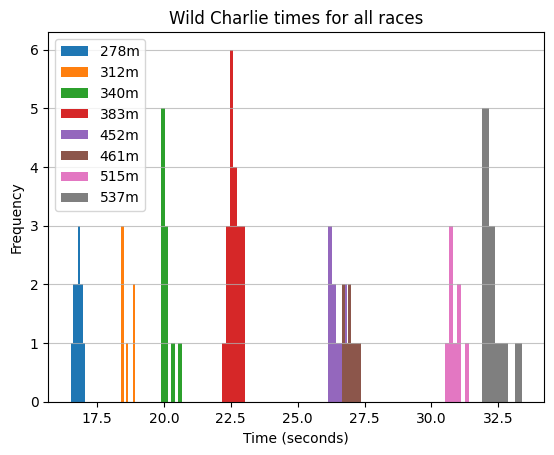

16.784545454545455
0.22527272727272793
0.47462904175021564


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

RUNNER_NAME = 'Wild Charlie'
RACE_LENGTH = 278

#Retrieving data on the Greyhound
formatted_name = RUNNER_NAME.lower().replace(' ', '-')

url = f'https://www.thegreyhoundrecorder.com.au/greyhounds/{formatted_name}/'

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
tables = pd.read_html(url, storage_options=headers)

races = tables[1]
dist_set = sorted(set(races['Dist']))

#Plotting histograms for each race length in the past
for dist in dist_set:
    plt.hist(races[races['Dist'] == dist]['Time'], bins=6)

plt.title(f'{RUNNER_NAME} times for all races')
plt.legend([f'{dist}m' for dist in dist_set])
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

#Creating Normal Distribution for given race
nd_mean = races[races['Dist']== RACE_LENGTH]['Time'].mean()
nd_var = 0
for time in races[races['Dist']== RACE_LENGTH]['Time']:
    nd_var += (nd_mean-time)**2
nd_sd = (nd_var)**(1/2)
print(str(nd_mean) + "\n" + str(nd_var) + "\n" + str(nd_sd))